## KMeans

1. Cluster data in the form GROUPS with Centroids.
2. How do we know how many K centers to initialize <br>
    ### ELBOW METHOD
    a. WCSS ( within cluster SUm of Square ) -> (Distance between Points and the Nearest centroid)**2 <br>
    b. we plot a graph of WCSS and K values. <br>
    c. The value of K for which the WCSS shows a drastic change and is constant afterwords -> THAT IS THE NUMBER OF K VALUES WE NEED<br>
3. To avoid Random Initiallization Trap -> use kmeans++ 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
%matplotlib inline

In [2]:
X,y = make_blobs(n_samples=1000 , centers = 3 , n_features= 2)


In [3]:
X

array([[-6.57961751, -6.84595767],
       [-9.39105161, -7.07423832],
       [ 1.69623941, -7.9419598 ],
       ...,
       [ 3.28721182, -5.24085654],
       [ 2.17716879, -4.93153622],
       [ 0.92574781, -4.77677053]], shape=(1000, 2))

In [4]:
y

array([1, 1, 0, 0, 0, 2, 2, 0, 1, 1, 0, 2, 0, 0, 2, 0, 1, 0, 0, 0, 1, 2,
       2, 2, 1, 1, 1, 0, 0, 2, 2, 2, 0, 0, 1, 1, 1, 0, 1, 0, 2, 0, 0, 2,
       1, 2, 0, 0, 1, 0, 1, 1, 0, 2, 1, 2, 0, 1, 0, 1, 1, 2, 2, 1, 2, 0,
       1, 2, 2, 1, 1, 2, 1, 2, 2, 0, 2, 0, 1, 2, 0, 1, 0, 2, 0, 2, 0, 1,
       0, 2, 0, 2, 0, 1, 1, 2, 0, 1, 2, 0, 1, 2, 2, 2, 2, 0, 1, 2, 2, 1,
       0, 0, 1, 0, 2, 2, 2, 0, 2, 1, 1, 1, 2, 2, 1, 2, 0, 0, 2, 0, 1, 0,
       0, 2, 1, 1, 2, 2, 2, 1, 0, 0, 2, 2, 1, 0, 0, 0, 2, 2, 0, 1, 0, 0,
       1, 0, 1, 2, 1, 0, 2, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 2, 0, 2, 1, 2,
       0, 1, 0, 0, 2, 0, 2, 0, 1, 2, 2, 2, 2, 0, 1, 2, 0, 1, 0, 0, 0, 2,
       0, 1, 0, 0, 2, 1, 0, 1, 0, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 1, 1, 0,
       0, 2, 2, 2, 0, 2, 0, 2, 0, 1, 2, 1, 0, 2, 2, 0, 1, 1, 1, 0, 0, 1,
       2, 1, 2, 1, 2, 0, 1, 0, 1, 2, 0, 1, 1, 2, 2, 0, 0, 0, 2, 0, 2, 1,
       2, 1, 2, 2, 0, 0, 2, 2, 1, 2, 0, 1, 0, 2, 1, 2, 1, 1, 0, 1, 2, 0,
       1, 0, 2, 2, 1, 1, 2, 0, 1, 0, 1, 1, 0, 1, 0,

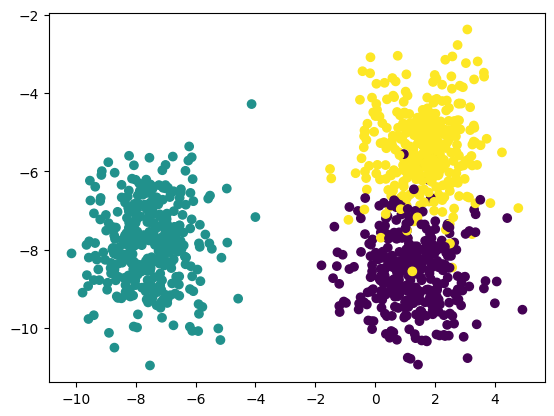

In [5]:
plt.scatter(X[:,0],X[:,1],c = y)

In [6]:
## Standerdization 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [7]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X,y , test_size=0.25)

In [8]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.cluster import KMeans

In [10]:
## Elbow Method 
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_test_scaled)
    
    wcss.append(kmeans.inertia_)


In [11]:
wcss

[514.9743693934919,
 247.628909220959,
 94.77993379306166,
 67.12348337306997,
 56.14955315942353,
 42.383656828066805,
 32.28525355364252,
 30.014652986968386,
 25.784662845402526,
 22.902328928875782]

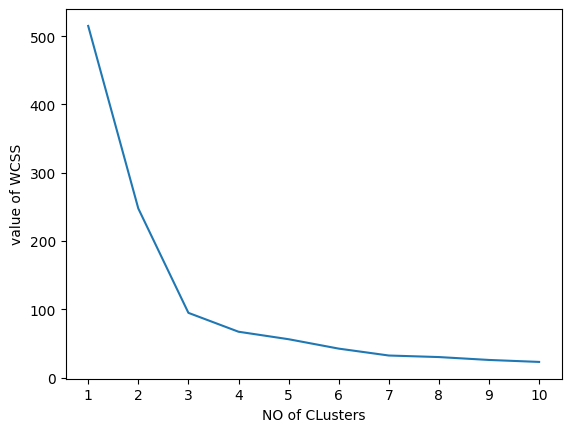

In [12]:
## plot elbow curve
sns.lineplot(x = range(1,11) , y=wcss)
plt.xticks(range(1,11))
plt.xlabel('NO of CLusters')
plt.ylabel('value of WCSS')
plt.show()

### Observation 
1. We can see elbow from k = 3

In [17]:
kmeans = KMeans(n_clusters=3,init="k-means++")
kmeans.fit_predict(X_train_scaled)

array([2, 0, 0, 0, 1, 2, 2, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 2, 0, 1, 2, 1,
       0, 1, 0, 2, 1, 2, 0, 1, 2, 2, 0, 1, 2, 1, 1, 2, 2, 2, 2, 2, 2, 1,
       0, 2, 1, 1, 0, 1, 2, 2, 0, 0, 1, 0, 0, 2, 0, 1, 1, 0, 0, 2, 1, 1,
       1, 2, 2, 0, 1, 0, 2, 2, 2, 2, 0, 1, 0, 1, 1, 2, 1, 0, 1, 2, 2, 2,
       0, 0, 2, 1, 0, 2, 1, 2, 1, 1, 0, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 0,
       1, 1, 1, 1, 2, 0, 2, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 2,
       1, 0, 2, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 2, 2, 2, 0, 2, 1, 0, 1,
       1, 2, 1, 2, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 2, 2, 2, 0, 1, 0, 0, 0,
       0, 0, 2, 2, 0, 0, 0, 2, 1, 2, 0, 0, 0, 2, 2, 1, 0, 1, 0, 2, 1, 1,
       0, 2, 0, 1, 1, 1, 2, 2, 0, 1, 1, 2, 1, 2, 0, 1, 2, 1, 2, 1, 0, 2,
       2, 1, 1, 0, 2, 0, 0, 1, 1, 0, 0, 0, 0, 2, 2, 1, 1, 0, 1, 2, 2, 2,
       0, 0, 1, 2, 1, 2, 2, 1, 2, 1, 1, 2, 0, 0, 2, 0, 0, 0, 0, 2, 2, 0,
       2, 1, 0, 0, 2, 2, 1, 2, 1, 0, 1, 1, 0, 2, 2, 0, 2, 2, 0, 0, 2, 2,
       1, 2, 1, 1, 1, 1, 2, 2, 1, 0, 1, 2, 0, 0, 0,

In [18]:
Y_pred = kmeans.predict(X_test_scaled)

In [19]:
Y_pred

array([1, 0, 0, 1, 2, 1, 2, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 2, 0, 1, 1,
       1, 1, 0, 2, 2, 0, 1, 1, 2, 1, 1, 0, 1, 0, 1, 2, 2, 2, 0, 1, 2, 2,
       2, 0, 0, 1, 2, 2, 0, 1, 1, 2, 1, 1, 1, 0, 1, 1, 1, 2, 0, 1, 1, 2,
       1, 2, 0, 2, 1, 0, 1, 2, 2, 2, 2, 0, 2, 2, 1, 1, 1, 2, 1, 1, 0, 0,
       0, 1, 2, 1, 2, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 2, 0, 0, 1,
       1, 1, 1, 0, 2, 1, 0, 0, 2, 2, 0, 0, 1, 1, 0, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 0, 1, 1, 0, 2, 1, 1, 0, 1, 0, 2, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 2, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 2, 1, 1, 0, 2, 0, 2, 1,
       2, 0, 2, 2, 1, 2, 0, 0, 1, 1, 0, 2, 1, 1, 0, 2, 0, 1, 1, 1, 2, 1,
       2, 0, 2, 0, 0, 1, 1, 1, 1, 2, 1, 0, 0, 0, 2, 2, 1, 0, 2, 2, 1, 1,
       2, 2, 1, 2, 1, 2, 0, 1, 2, 1, 2, 2, 0, 1, 0, 0, 2, 1, 2, 1, 1, 1,
       1, 0, 1, 2, 1, 2, 0, 0], dtype=int32)

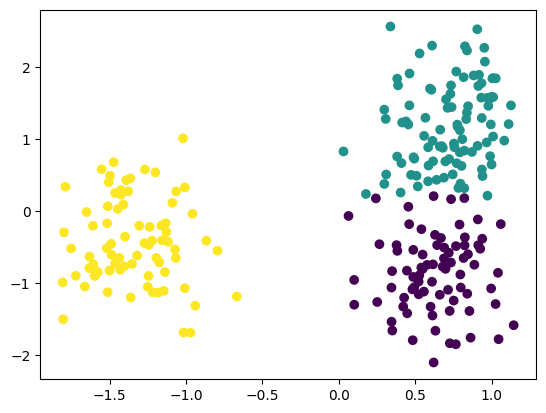

In [20]:
plt.scatter(X_test_scaled[:,0],X_test_scaled[:,1],c=Y_pred)

## Validating the K value
1. knee Locater 
2. Shilhoutte Scoring

In [22]:
## Validating the K value 
!pip install kneed

In [26]:
from kneed import KneeLocator

In [27]:
kl = KneeLocator(range(1,11),wcss,curve = 'convex',direction = 'decreasing')

In [28]:
kl.elbow

np.int64(3)

### Thus Validated -> k = 3

In [29]:
## Silhoutte scoring 
from sklearn.metrics import silhouette_score

In [31]:
silhouette_coeff = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coeff.append(score)

In [32]:
silhouette_coeff


[0.43953378563206186,
 0.6129260533890981,
 0.5486317146246749,
 0.46923922547590824,
 0.4279092336747291,
 0.4230258378115714,
 0.3977752389844699,
 0.371256161183807,
 0.3740185648636935]

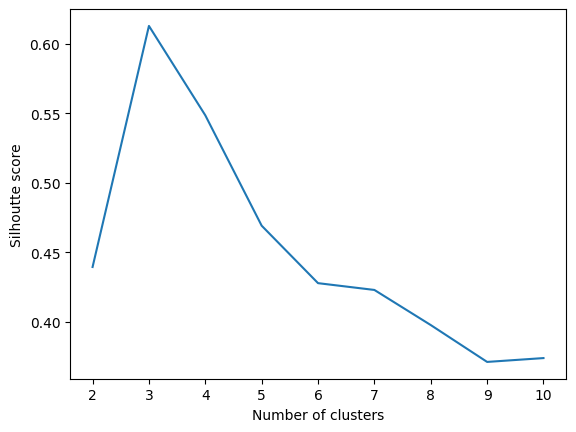

In [34]:
plt.plot(range(2,11),silhouette_coeff)
plt.xticks(range(2,11))
plt.xlabel("Number of clusters")
plt.ylabel('Silhoutte score')
plt.show()

### The value is Maximum at K  = 3 

Thus K = 3